# Mérési notebook
---
# **1. mérési fázis**. A	Modellek tesztelése tanítás nélkül.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 2. modell **DenseNet121** modell tanítás nélküli tesztelése

#### A  DenseNet121@ImageNet1k modell tanítás nélküli futtatása a saját ImageNet180K adathalmaz Test részhalmazán. (teszt elemszám: 18k).


---



✅ 1. Telepítő + GPU ellenőrző blokk

In [ ]:
# --- Telepítés ---
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn

# --- GPU ellenőrzés ---
import torch
if torch.cuda.is_available():
    print("✅ GPU aktív:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Nincs GPU! Runtime > Change runtime type > GPU")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 189.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 202.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 153.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 166.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 155.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 214.3 MB/s eta 0:00:00
✅ GPU aktív: NVIDIA A100-SXM4-40GB


✅ 2. Drive csatolás + ZIP kicsomagolás

In [ ]:
from google.colab import drive
import zipfile, os

# Csatolás
drive.mount('/content/drive')

# Útvonalak
diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

# Kicsomagolás
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("📁 Kicsomagolva:", extract_path)


Mounted at /content/drive
📁 Kicsomagolva: /content/imagenet_splitted_db


✅ 3. DenseNet121 modell betöltés és tesztadat betöltése

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from tqdm import tqdm
import os

# --- Paraméterek ---
batch_size = 64
num_workers = 2
test_dir = "/content/imagenet_splitted_db/imagenet_splitted_db/test"

# --- Transzformáció ---
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Tesztadat betöltése ---
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# --- DenseNet121 modell betöltése ---
model = models.densenet121(pretrained=True)
model.eval().cuda()

# --- Predikció ---
all_preds = []
all_probs = []
all_labels = []

start_time = time.perf_counter()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference"):
        inputs = inputs.cuda()
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

end_time = time.perf_counter()
inference_time = end_time - start_time


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 177MB/s]
Inference: 100%|██████████| 284/284 [00:25<00:00, 11.30it/s]


✅ 4. Metrikák számítása és kiírása

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score
from torchvision.models import DenseNet121_Weights

# --- Címkék normalizálása ---
normalized_class_names = [name.replace("_", " ").lower() for name in test_dataset.classes]

# --- ImageNet kategóriák lekérése ---
imagenet_categories = DenseNet121_Weights.DEFAULT.meta["categories"]
imagenet_name_to_index = {name.lower(): idx for idx, name in enumerate(imagenet_categories)}

# --- Saját osztályaidhoz tartozó ImageNet indexek kigyűjtése ---
imagenet_indices = [imagenet_name_to_index[name] for name in normalized_class_names]

# --- Valószínűségi mátrix szűkítése csak saját kategóriákra (shape: N x 114) ---
y_probs = np.array(all_probs)
y_probs_subset = y_probs[:, imagenet_indices]

# --- y_true változatlan marad (ImageFolder által biztosított 0–113 közti osztályindexek) ---
y_true = np.array(all_labels)

# --- y_pred újraszámolása (a szűkített 114 osztályon belül) ---
y_pred = np.argmax(y_probs_subset, axis=1)

# --- Metrikák számítása ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
top5 = top_k_accuracy_score(y_true, y_probs_subset, k=5)

# --- Kiírás ---
print(f"\n🔍 Vizsgálat eredményei (DenseNet121 @ ImageNet1k, saját 114 osztály):")
print(f"✅ Top-1 Accuracy:  {accuracy:.4f}")
print(f"✅ Top-5 Accuracy:  {top5:.4f}")
print(f"🎯 Precision:       {precision:.4f}")
print(f"🎯 Recall:          {recall:.4f}")
print(f"🎯 F1-score:        {f1:.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Vizsgálat eredményei (DenseNet121 @ ImageNet1k, saját 114 osztály):
✅ Top-1 Accuracy:  0.4498
✅ Top-5 Accuracy:  0.7806
🎯 Precision:       0.3874
🎯 Recall:          0.3611
🎯 F1-score:        0.3408
⏱️ Inference time:  25.15 sec


✅ 5. Confusion Matrix megjelenítése

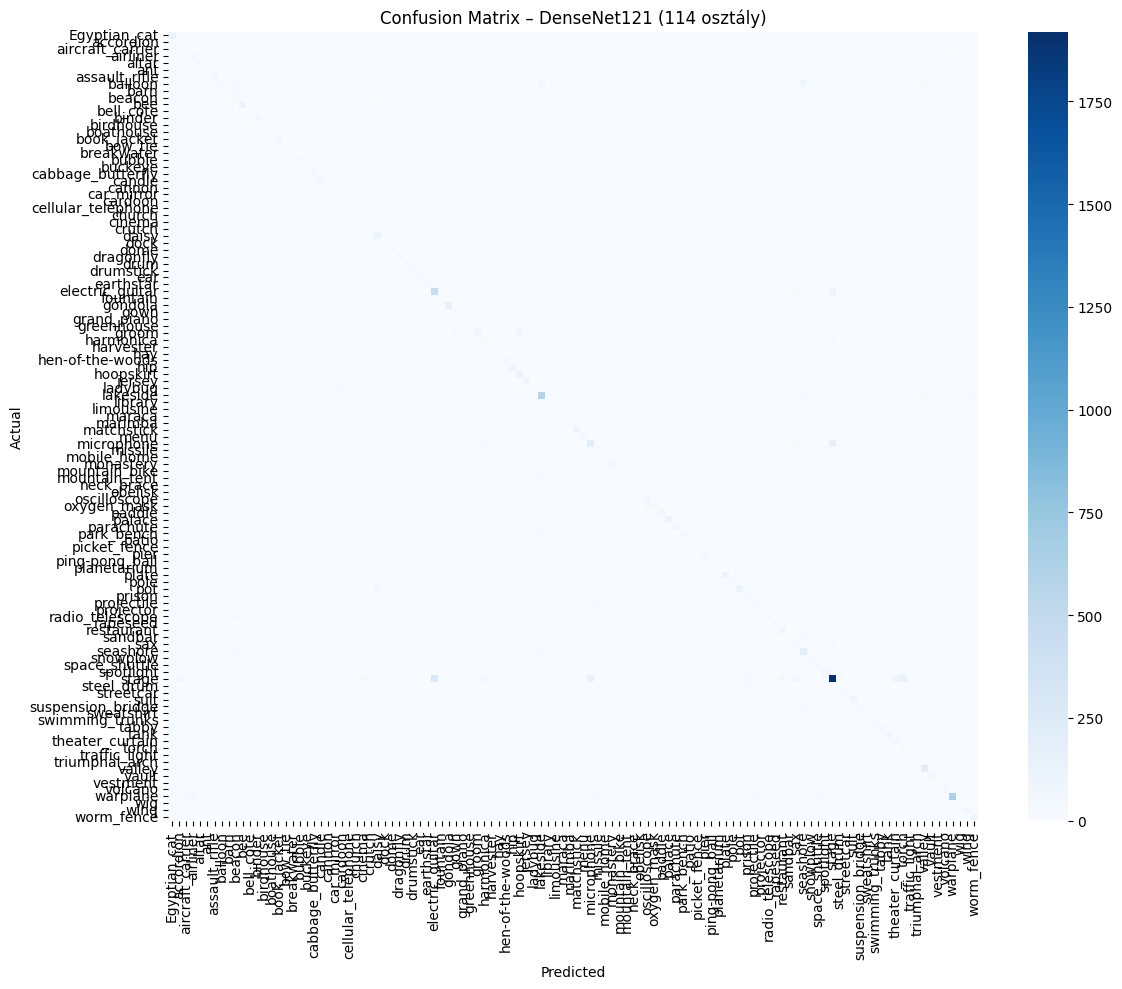

In [ ]:
conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – DenseNet121 (114 osztály)")
plt.tight_layout()
plt.show()

Kategória remapping ellenőrzés

In [ ]:
# --- 1. y_true / y_pred tartomány-ellenőrzés ---
print("✅ Index-tartomány ellenőrzés:")
print(f" - y_true: {np.min(y_true)} – {np.max(y_true)}")
print(f" - y_pred: {np.min(y_pred)} – {np.max(y_pred)}")
print(f" - y_probs_subset.shape: {y_probs_subset.shape}")

if np.max(y_true) >= len(class_names) or np.max(y_pred) >= len(class_names):
    print("⚠️ Figyelem: valamelyik index kilóg a 114 kategória tartományából!")
else:
    print("✅ Minden index a megfelelő tartományban van.")

print("\n📋 Kategória-párosítás ellenőrzés:")
print(f"{'Lokális index':<15} {'Mappanév (raw)':<30} {'Normalizált név':<30} {'ImageNet index':<15}")
print("-" * 95)
for i, (raw, norm, idx) in enumerate(zip(class_names, normalized_class_names, imagenet_indices)):
    print(f"{i:<15} {raw:<30} {norm:<30} {idx:<15}")


✅ Index-tartomány ellenőrzés:
 - y_true: 0 – 113
 - y_pred: 0 – 113
 - y_probs_subset.shape: (18172, 114)
✅ Minden index a megfelelő tartományban van.

📋 Kategória-párosítás ellenőrzés:
Lokális index   Mappanév (raw)                 Normalizált név                ImageNet index 
-----------------------------------------------------------------------------------------------
0               Egyptian_cat                   egyptian cat                   285            
1               accordion                      accordion                      401            
2               aircraft_carrier               aircraft carrier               403            
3               airliner                       airliner                       404            
4               altar                          altar                          406            
5               ant                            ant                            310            
6               assault_rifle                  assault rifle

✅ 6. Osztályonkénti metrikák kiírása

In [ ]:
from sklearn.metrics import classification_report

# --- Eredeti fájlnév-alapú osztálynevek ---
class_names = test_dataset.classes

# --- Részletes metrikák osztályonként ---
report = classification_report(
    y_true, y_pred, target_names=class_names, zero_division=0
)

print("\n📋 Részletes osztályonkénti metrikák (Precision / Recall / F1):\n")
print(report)



📋 Részletes osztályonkénti metrikák (Precision / Recall / F1):

                    precision    recall  f1-score   support

      Egyptian_cat       0.64      0.83      0.73       145
         accordion       0.05      0.15      0.08        47
  aircraft_carrier       0.12      0.23      0.16        39
          airliner       0.38      0.56      0.45        80
             altar       0.31      0.53      0.39        59
               ant       0.29      0.24      0.26        95
     assault_rifle       0.44      0.46      0.45        91
           balloon       0.35      0.11      0.17       338
              barn       0.45      0.09      0.15       111
            beacon       0.14      0.45      0.21        62
               bee       0.69      0.48      0.57       212
         bell_cote       0.18      0.27      0.21        77
            binder       0.41      0.38      0.39       105
         birdhouse       0.31      0.07      0.11       116
         boathouse       0.25     

✅ 7. GPU memóriahasználat és statisztika

In [ ]:
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")


💾 GPU memória (lefoglalt): 1.04 GB
💾 GPU memória (használt):  0.07 GB


✅ 8. CSV export + gyenge osztályok kiírása

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1-score": f1_per_class,
})

# Mentés
df_metrics.to_csv("/content/densenet121_test_metrics.csv", index=False)
print("📁 Mentve: densenet121_test_metrics.csv")

# Legrosszabb osztályok
worst_classes = df_metrics.sort_values("F1-score").head(10)
print("😢 Legrosszabbul teljesítő osztályok:")
print(worst_classes)


📁 Mentve: densenet121_test_metrics.csv
😢 Legrosszabbul teljesítő osztályok:
               Class  Precision    Recall  F1-score
64     mountain_tent   0.052632  0.008264  0.014286
16           bow_tie   0.250000  0.029851  0.053333
1          accordion   0.053030  0.148936  0.078212
74      picket_fence   0.750000  0.050847  0.095238
13         birdhouse   0.307692  0.068966  0.112676
73             patio   0.550000  0.076389  0.134146
77       planetarium   0.117647  0.161290  0.136054
84   radio_telescope   0.164706  0.129630  0.145078
8               barn   0.454545  0.090090  0.150376
103            torch   0.102339  0.301724  0.152838
